## Załadowanie obrazu

In [164]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import math
from skimage import exposure

img = Image.open('./src/example_images/SADDLE_PE.jpg').convert('L')
img_matrix = np.array(img)/255

(img_height, img_width) = img_matrix.shape
print(img_height, img_width)


876 1053


## Parametry wejściowe

In [165]:
N_detectors = 240
distance_between_emiters = math.sqrt(pow(img_width,2)+pow(img_height,2))/N_detectors   #pixels
N_scans = 180
angle_coverage = 180    #degrees


## Pętla skanowania

In [166]:
def calculate_emitter_coordinates(alpha_deg, num_emiters, distance_between, radius, image_shape):
    """
    alpha_deg: aktualny kąt obrotu w stopniach
    num_emiters: liczba emiterów (detektorów)
    distance_between: odległość między sąsiednimi emiterami (w pikselach)
    radius: promień na jakim znajduje się głowica od środka obrazu
    image_shape: krotka (height, width) obrazu wejściowego
    """
    
    # 1. Konwersja kąta na radiany
    alpha = np.radians(alpha_deg)
    
    # 2. Wyznaczenie środka obrazu (punkt odniesienia)
    center_x = image_shape[1] / 2
    center_y = image_shape[0] / 2
    
    # 3. Wyznaczenie centralnego punktu głowicy (środek linii emiterów)
    # Głowica krąży po okręgu o promieniu 'radius'
    head_center_x = center_x + radius * np.cos(alpha)
    head_center_y = center_y + radius * np.sin(alpha)
    
    # 4. Wyznaczenie wektora prostopadłego do kierunku naświetlania
    # To po tej linii będziemy "rozsuwać" emitery
    # Wektor prostopadły do [cos(a), sin(a)] to [-sin(a), cos(a)]
    v_x = -np.sin(alpha)
    v_y = np.cos(alpha)
    
    emitters = []
    
    # 5. Wyznaczenie pozycji każdego emitera
    # Chcemy, aby emitery były rozłożone symetrycznie względem head_center
    offset_start = -((num_emiters - 1) * distance_between) / 2
    
    for i in range(num_emiters):
        current_offset = offset_start + i * distance_between
        
        # Nowe współrzędne = środek głowicy + przesunięcie wzdłuż wektora v
        ex = head_center_x + current_offset * v_x
        ey = head_center_y + current_offset * v_y
        
        emitters.append((ex.item(), ey.item()))
        
    return emitters



## Algorytm bresenhama

In [167]:
def get_bresenham_pixels(x0, y0, x1, y1):
    """
    Zwraca listę punktów (x, y) łączących (x0, y0) i (x1, y1)
    """
    # Zaokrąglamy współrzędne do najbliższych pikseli
    x0, y0 = int(round(x0)), int(round(y0))
    x1, y1 = int(round(x1)), int(round(y1))
    
    pixels = []
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy

    while True:
        pixels.append((x0, y0))
        
        if x0 == x1 and y0 == y1:
            break
            
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x0 += sx
        if e2 < dx:
            err += dx
            y0 += sy
            
    return pixels

## Filtrowanie i sumowanie

In [168]:
def filter_sum_nornmalize(pixels):
    sum = 0
    counter = 0
    for pixel_cords in pixels:
        if pixel_cords[0] >= 0 and pixel_cords[0] < img_matrix.shape[1] and pixel_cords[1] >= 0 and pixel_cords[1] < img_matrix.shape[0]:
            sum += img_matrix[pixel_cords[1]][pixel_cords[0]]
            counter += 1
            #do potencjalnej alternatywnej normalizacji
    if counter == 0:
        return 0
    return sum/counter

In [169]:
def show_sinogram(sinogram_matrix):
    sinogram_np = np.array(sinogram_matrix)

    plt.figure(figsize=(18, 8))
    # aspect='auto' jest kluczowe! 
    # Bez tego, jeśli masz np. 180 skanów i 720 detektorów, 
    # obrazek będzie bardzo wąskim paskiem.
    plt.imshow(sinogram_np, cmap='gray', aspect='auto')

    plt.xlabel("Indeks detektora")
    plt.ylabel("Indeks skanu (Kąt)")
    plt.title("Sinogram")
    plt.colorbar()
    plt.show()

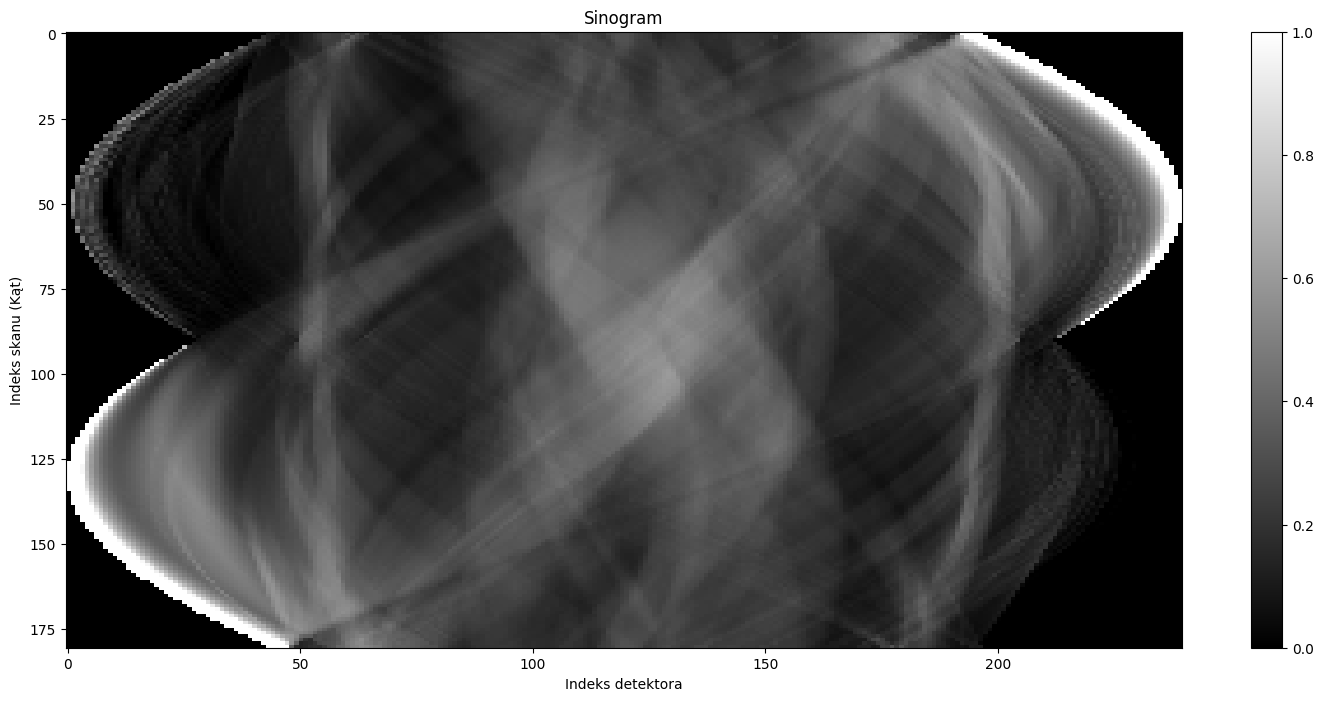

In [170]:
sinogram = []
angle = 0
while angle <= angle_coverage:
    #głowica w nowej pozycji

    radius = math.sqrt(pow(img_width,2)+pow(img_height, 2))/2
    emiters_cords = calculate_emitter_coordinates(angle, N_detectors, distance_between_emiters, radius, img_matrix.shape)
    detectors_cords = calculate_emitter_coordinates(angle+180, N_detectors, distance_between_emiters, radius, img_matrix.shape)[::-1]
    
    sinogram_row = []
    for i in range(N_detectors):
        bresenham_pixels = get_bresenham_pixels(emiters_cords[i][0], emiters_cords[i][1], detectors_cords[i][0], detectors_cords[i][1])
        sinogram_row.append(filter_sum_nornmalize(bresenham_pixels))
    sinogram.append(sinogram_row)
    angle += angle_coverage/N_scans
    
    # clear_output(wait=True)
    # plt.imshow(np.array(sinogram), cmap='gray', aspect='auto')
    # plt.show()


show_sinogram(sinogram)


## Filtr

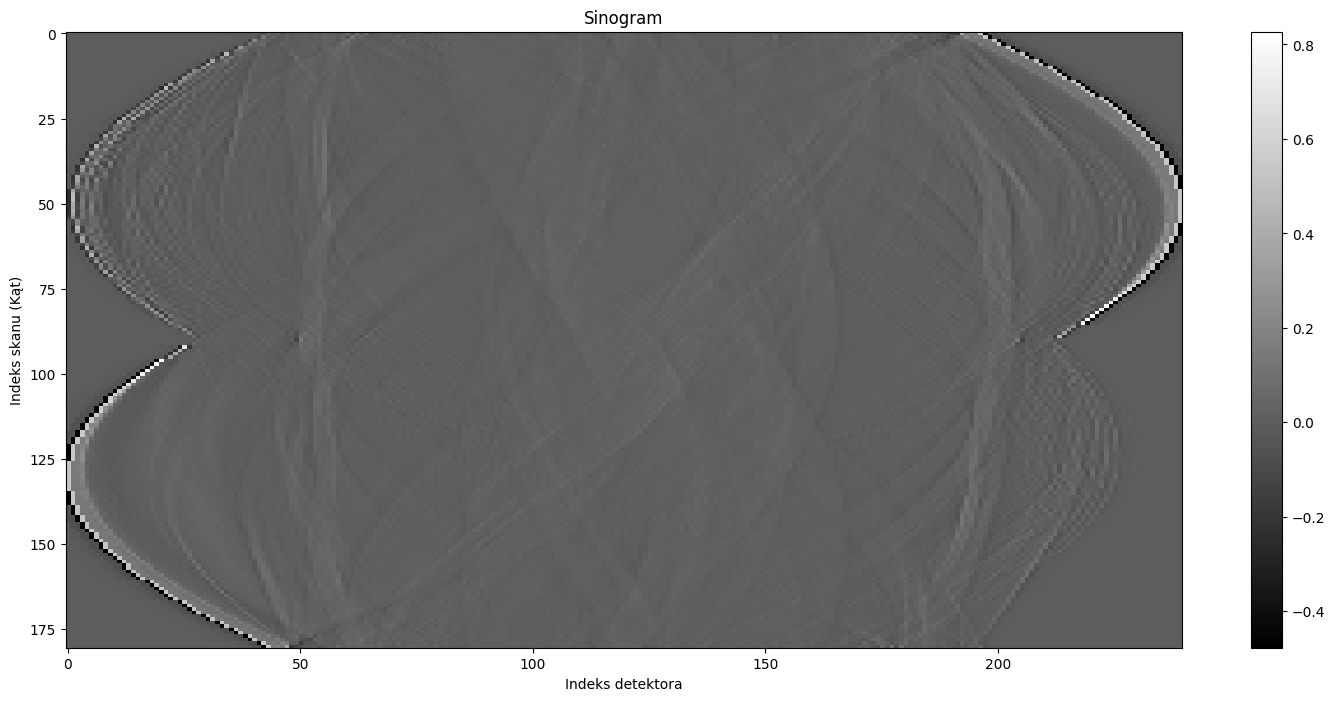

In [171]:
filter = []
for k in range(-10,11):
    if k == 0:
        filter.append(1)
    elif k%2 == 0:
        filter.append(0)
    else:
        filter.append(-4/pow(math.pi,2)/pow(k,2))

filtered_sinogram = []

for i in range(len(sinogram)):
    filtered_sinogram.append(np.convolve(sinogram[i], filter, mode='same'))

show_sinogram(filtered_sinogram)

## Obraz wyjściowy (bez filtra)

In [172]:
output_img_matrix = [[0 for _ in range(img_width)] for _ in range(img_height)]
ray_counter_matrix = [[0 for _ in range(img_width)] for _ in range(img_height)]

def add_ray_trace(brightness, pixels):
    for pixel_cords in pixels:
        if pixel_cords[0] >= 0 and pixel_cords[0] < img_matrix.shape[1] and pixel_cords[1] >= 0 and pixel_cords[1] < img_matrix.shape[0]:
            output_img_matrix[pixel_cords[1]][pixel_cords[0]] += brightness
            ray_counter_matrix[pixel_cords[1]][pixel_cords[0]] += 1
            #potencjalnie znormalizować

In [173]:

# angle = 0
# sinogram_row_counter = 0
# while angle <= angle_coverage:
#     #głowica w nowej pozycji
#     radius = math.sqrt(pow(img_width,2)+pow(img_height, 2))/2

#     emiters_cords = calculate_emitter_coordinates(angle, N_detectors, distance_between_emiters, radius, img_matrix.shape)
#     detectors_cords = calculate_emitter_coordinates(angle+180, N_detectors, distance_between_emiters, radius, img_matrix.shape)[::-1]
    
#     for i in range(N_detectors):
#         bresenham_pixels = get_bresenham_pixels(emiters_cords[i][0], emiters_cords[i][1], detectors_cords[i][0], detectors_cords[i][1])
#         add_ray_trace(sinogram[sinogram_row_counter][i], bresenham_pixels)
    
#     angle += angle_coverage/N_scans
#     sinogram_row_counter += 1


# #normalizacja
# for y in range(img_height):
#     for x in range(img_width):
#         if ray_counter_matrix[y][x] != 0:
#             output_img_matrix[y][x] = output_img_matrix[y][x]/ray_counter_matrix[y][x]
    
# plt.imshow(output_img_matrix, cmap='gray')
# plt.axis('off')
# plt.show()



## Obraz wyjściowy (z filtrem)

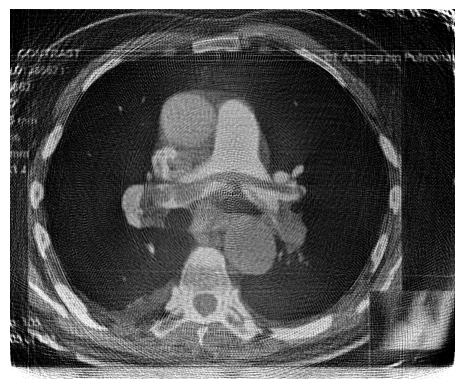

In [174]:
output_img_matrix = [[0 for _ in range(img_width)] for _ in range(img_height)]
ray_counter_matrix = [[0 for _ in range(img_width)] for _ in range(img_height)]

angle = 0
sinogram_row_counter = 0
while angle <= angle_coverage:
    #głowica w nowej pozycji
    radius = math.sqrt(pow(img_width,2)+pow(img_height, 2))/2

    emiters_cords = calculate_emitter_coordinates(angle, N_detectors, distance_between_emiters, radius, img_matrix.shape)
    detectors_cords = calculate_emitter_coordinates(angle+180, N_detectors, distance_between_emiters, radius, img_matrix.shape)[::-1]
    
    for i in range(N_detectors):
        bresenham_pixels = get_bresenham_pixels(emiters_cords[i][0], emiters_cords[i][1], detectors_cords[i][0], detectors_cords[i][1])
        add_ray_trace(filtered_sinogram[sinogram_row_counter][i], bresenham_pixels)
    
    angle += angle_coverage/N_scans
    sinogram_row_counter += 1

#normalizacja
for y in range(img_height):
    for x in range(img_width):
        if ray_counter_matrix[y][x] != 0:
            output_img_matrix[y][x] = output_img_matrix[y][x]/ray_counter_matrix[y][x]

p_low, p_high = np.percentile(output_img_matrix, (20, 98))

output_array = np.array(output_img_matrix)
rescaled_img = exposure.rescale_intensity(output_array, in_range=(p_low, p_high), out_range=(0, 1))

plt.imshow(rescaled_img, cmap='gray')
plt.axis('off')
plt.show()

